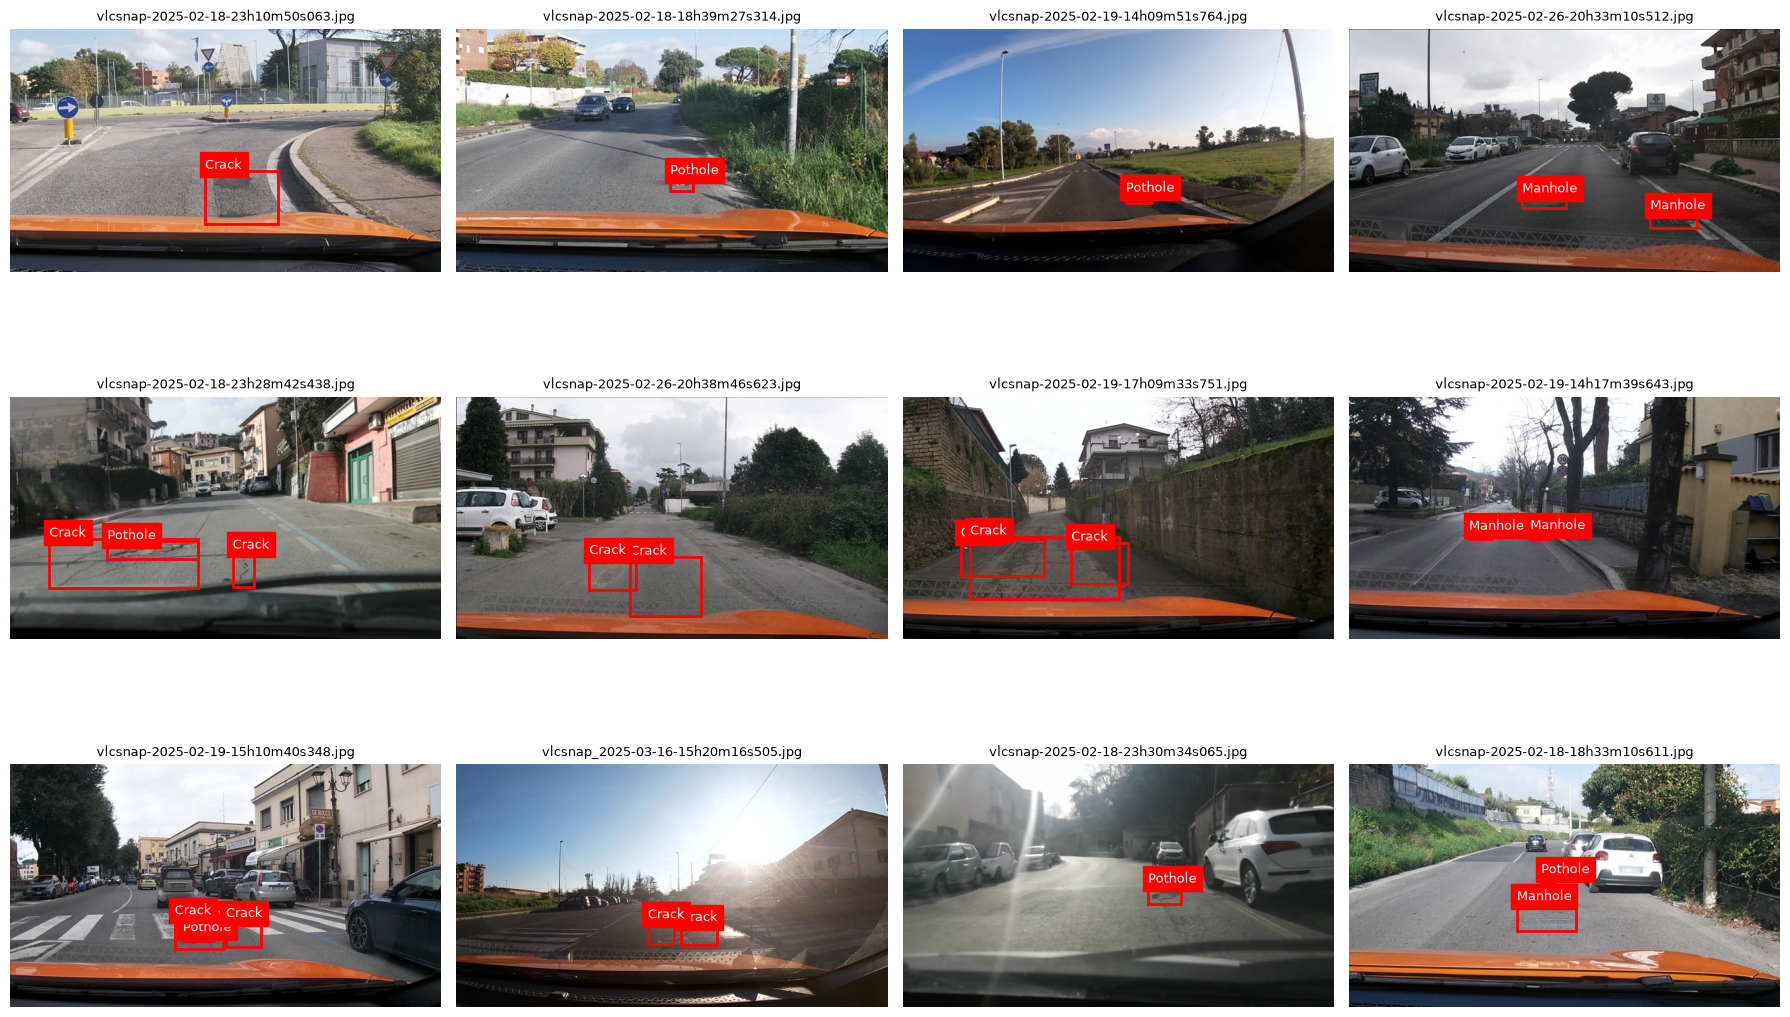

In [5]:
from pathlib import Path
import random
import math

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# แก้ไข path ให้ตรงกับโครงสร้างข้อมูล
IMAGE_DIR = Path("data/images")
LABEL_DIR = Path("data/labels-YOLO")

# ชื่อคลาส หรือใช้ None หากไม่มีไฟล์ชื่อคลาส
CLASS_NAMES = ['Pothole', 'Crack', 'Manhole']
# ตัวอย่าง: CLASS_NAMES = ["cat", "dog", "person"]

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths = [
    p for p in IMAGE_DIR.rglob("*")
    if p.suffix.lower() in image_extensions
]

if not image_paths:
    raise FileNotFoundError(f"ไม่พบรูปภาพใน {IMAGE_DIR}")

sample_paths = random.sample(image_paths, min(12, len(image_paths)))

cols = 4
rows = math.ceil(len(sample_paths) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = list(axes.flat) if hasattr(axes, "flat") else [axes]

for ax, image_path in zip(axes, sample_paths):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image.shape[:2]

    ax.imshow(image)
    ax.axis("off")
    ax.set_title(image_path.name, fontsize=9)

    label_path = LABEL_DIR / f"{image_path.stem}.txt"

    if label_path.exists():
        for line in label_path.read_text().splitlines():
            values = line.split()

            if len(values) < 5:
                continue

            class_id, xc, yc, box_w, box_h = map(float, values[:5])

            box_w *= width
            box_h *= height
            x = (xc * width) - box_w / 2
            y = (yc * height) - box_h / 2

            rectangle = patches.Rectangle(
                (x, y),
                box_w,
                box_h,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )
            ax.add_patch(rectangle)

            label = str(int(class_id))
            if CLASS_NAMES and int(class_id) < len(CLASS_NAMES):
                label = CLASS_NAMES[int(class_id)]

            ax.text(
                x,
                max(0, y - 3),
                label,
                color="white",
                fontsize=9,
                backgroundcolor="red"
            )

# ซ่อนช่องว่างที่เหลือ
for ax in axes[len(sample_paths):]:
    ax.axis("off")

plt.tight_layout()
plt.show()